# Case Study Report

This report presents a comprehensive climate analysis of major Indian cities during the 2024-2025 period, utilizing a high-integrity dataset of 7,310 records. 

By examining key meteorological variables—including temperature, precipitation, humidity, and air quality—the study transitions from raw data to actionable insights.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
print("Displaying a part of dataset:-")
df = pd.read_csv('Indian_Climate_Dataset_2024_2025.csv')
df.head(10)

Displaying a part of dataset:-


,Date,City,State,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),AQI,AQI_Category,Pressure (hPa),Cloud_Cover (%)
0,2024-01-01,Mumbai,Maharashtra,32.5,18.0,25.2,77.6,0.0,3.3,259,Poor,1020.3,62.1
1,2024-01-01,Delhi,Delhi,25.4,10.7,18.1,84.1,0.0,9.0,130,Moderate,1008.4,46.0
2,2024-01-01,Bengaluru,Karnataka,37.2,30.8,34.0,49.0,3.7,6.6,54,Satisfactory,1008.0,61.3
3,2024-01-01,Chennai,Tamil Nadu,37.2,30.4,33.8,34.2,9.5,9.0,176,Moderate,993.4,70.0
4,2024-01-01,Kolkata,West Bengal,27.4,17.5,22.5,32.2,9.1,9.2,97,Satisfactory,1008.2,56.9
5,2024-01-01,Hyderabad,Telangana,44.4,31.6,38.0,91.1,51.9,4.0,140,Moderate,996.9,9.3
6,2024-01-01,Ahmedabad,Gujarat,32.8,25.1,28.9,83.9,0.0,5.2,345,Very Poor,1018.1,12.1
7,2024-01-01,Jaipur,Rajasthan,40.4,33.5,37.0,30.4,8.2,19.7,75,Satisfactory,992.6,39.1
8,2024-01-01,Lucknow,Uttar Pradesh,42.3,31.0,36.6,51.5,0.0,18.8,186,Moderate,1012.3,89.3
9,2024-01-01,Bhopal,Madhya Pradesh,27.4,15.3,21.3,79.5,0.0,14.0,73,Satisfactory,1005.0,7.4


In [3]:
print("Details of dataset:-\n")
print("Dataset Shape:", df.shape)
print("\nColumn Names and Types:")
print(df.info())

Details of dataset:-

Dataset Shape: (7310, 13)

Column Names and Types:
<class 'pandas.DataFrame'>
RangeIndex: 7310 entries, 0 to 7309
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  7310 non-null   str    
 1   City                  7310 non-null   str    
 2   State                 7310 non-null   str    
 3   Temperature_Max (°C)  7310 non-null   float64
 4   Temperature_Min (°C)  7310 non-null   float64
 5   Temperature_Avg (°C)  7310 non-null   float64
 6   Humidity (%)          7310 non-null   float64
 7   Rainfall (mm)         7310 non-null   float64
 8   Wind_Speed (km/h)     7310 non-null   float64
 9   AQI                   7310 non-null   int64  
 10  AQI_Category          7310 non-null   str    
 11  Pressure (hPa)        7310 non-null   float64
 12  Cloud_Cover (%)       7310 non-null   float64
dtypes: float64(8), int64(1), str(4)
memory usage: 742.6 KB
None


In [4]:
# Checking for missing values
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Date                    0
City                    0
State                   0
Temperature_Max (°C)    0
Temperature_Min (°C)    0
Temperature_Avg (°C)    0
Humidity (%)            0
Rainfall (mm)           0
Wind_Speed (km/h)       0
AQI                     0
AQI_Category            0
Pressure (hPa)          0
Cloud_Cover (%)         0
dtype: int64


The analyzed dataset is highly robust, comprising 7,310 complete records across 13 distinct variables (including Temperature, Humidity, Rainfall, Wind Speed, and AQI) with zero missing values. 

This structural integrity allows for high-confidence insights into the macro and micro-climatic trends across major Indian cities over the two-year period(2024-2025).

In [5]:
hottest_city = df.groupby('City')['Temperature_Max (°C)'].mean().idxmax()
cleanest_city = df.groupby('City')['AQI'].mean().idxmin()
cloudy_city = df.groupby('City')['Cloud_Cover (%)'].mean().idxmax()

print(f"\nHottest City (Avg Max Temp): {hottest_city}")
print(f"City with Cleanest Air (Lowest Avg AQI): {cleanest_city}")
print(f"Cloudy city: {cloudy_city}")


Hottest City (Avg Max Temp): Kolkata
City with Cleanest Air (Lowest Avg AQI): Mumbai
Cloudy city: Lucknow


Thermal Peak: Kolkata recorded the highest average maximum temperatures.

Air Quality Champion: Mumbai achieved the lowest average Air Quality Index (AQI), categorizing it as the city with the cleanest air in this specific dataset.

Maximum Cloud Density: Lucknow experienced the highest average cloud cover.

C:\Users\venum\AppData\Local\Temp\ipykernel_11220\2397982804.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_wind.index, y=avg_wind.values, palette='deep')


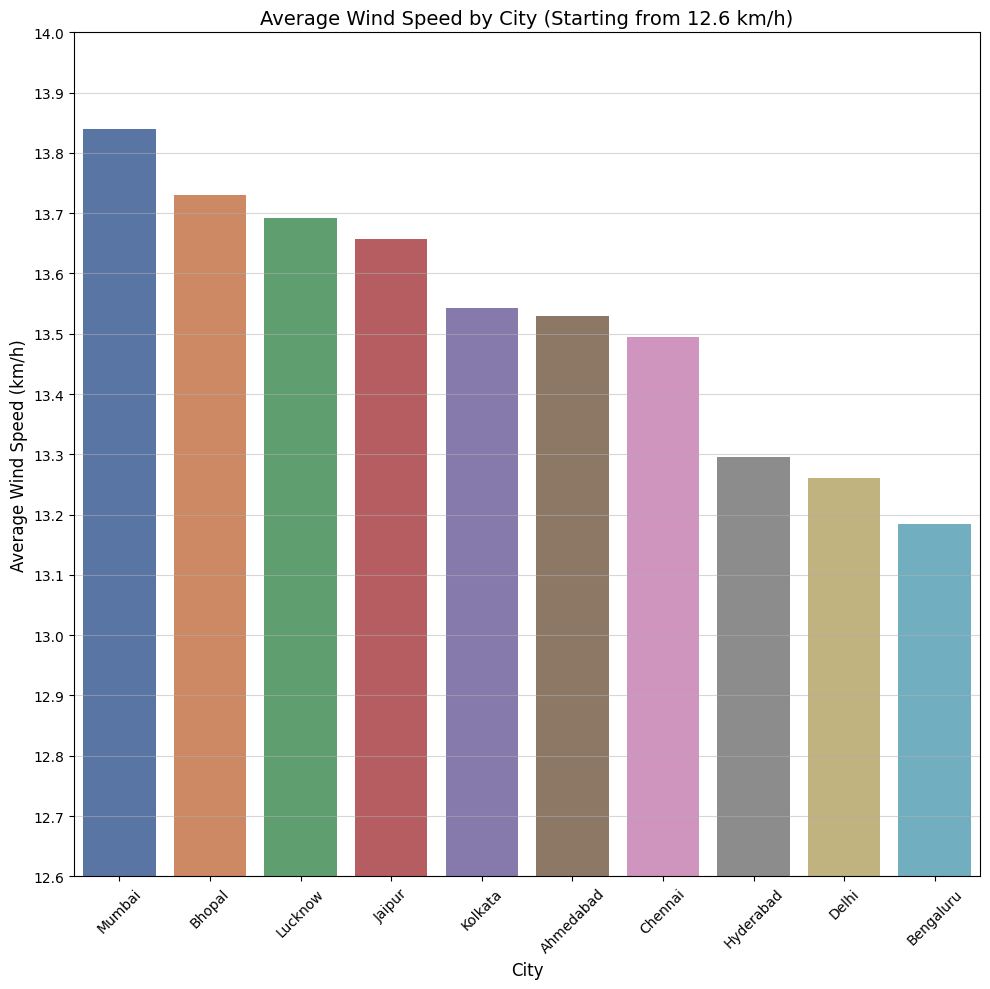

In [6]:
avg_wind = df.groupby('City')['Wind_Speed (km/h)'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 10))
sns.barplot(x=avg_wind.index, y=avg_wind.values, palette='deep')
start_y = 12.6
max_y = avg_wind.max()

plt.ylim(start_y, max_y + 0.1) 
ticks = np.arange(start_y, max_y + 0.2, 0.1)
plt.yticks(ticks)

plt.title('Average Wind Speed by City (Starting from 12.6 km/h)', fontsize=14)
plt.xlabel('City', fontsize=12)
plt.ylabel('Average Wind Speed (km/h)', fontsize=12)
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

A bar chart analysis setting a baseline of 12 km/h reveals that Mumbai experiences the highest average wind speeds. Inland cities like Bhopal and Lucknow follow closely, suggesting strong localized wind corridors.

Conversely, Bengaluru and Delhi sit at the bottom, averaging a stagnant 13.2km/h, respectively. This lack of wind dispersion in Delhi is a known compounding factor for its historical air quality challenges.

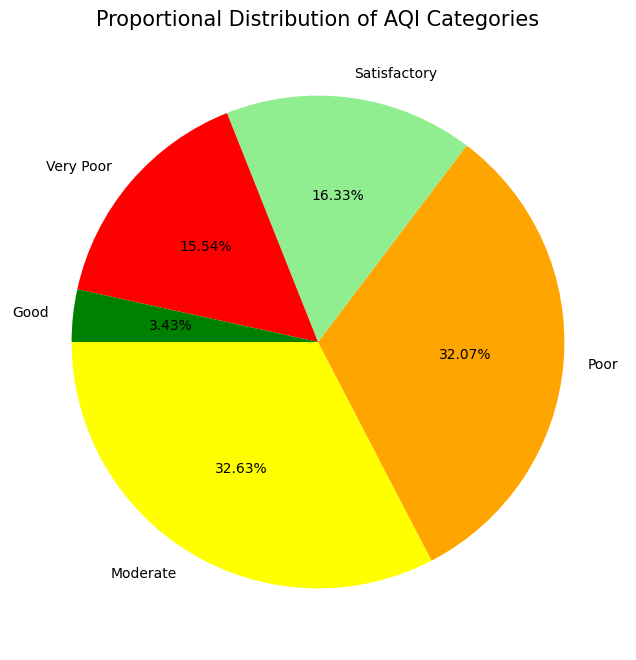

In [7]:
plt.figure(figsize=(8, 8))
counts = df['AQI_Category'].value_counts()
color_map = {
    'Good': 'green',
    'Satisfactory': 'lightgreen',
    'Moderate': 'yellow',
    'Poor': 'orange',
    'Very Poor': 'red',
    'Severe': 'darkred'
}
colours = [color_map.get(category, 'gray') for category in counts.index]

plt.pie(counts, labels=counts.index, colors=colours, autopct='%1.2f%%', startangle =180)
plt.title('Proportional Distribution of AQI Categories', fontsize=15)
plt.show()

The analysis successfully categorizes the national respiratory health landscape into six distinct buckets (Good to Severe). 

This allows policymakers to immediately grasp what proportion of the year falls into hazardous territory versus breathable conditions.

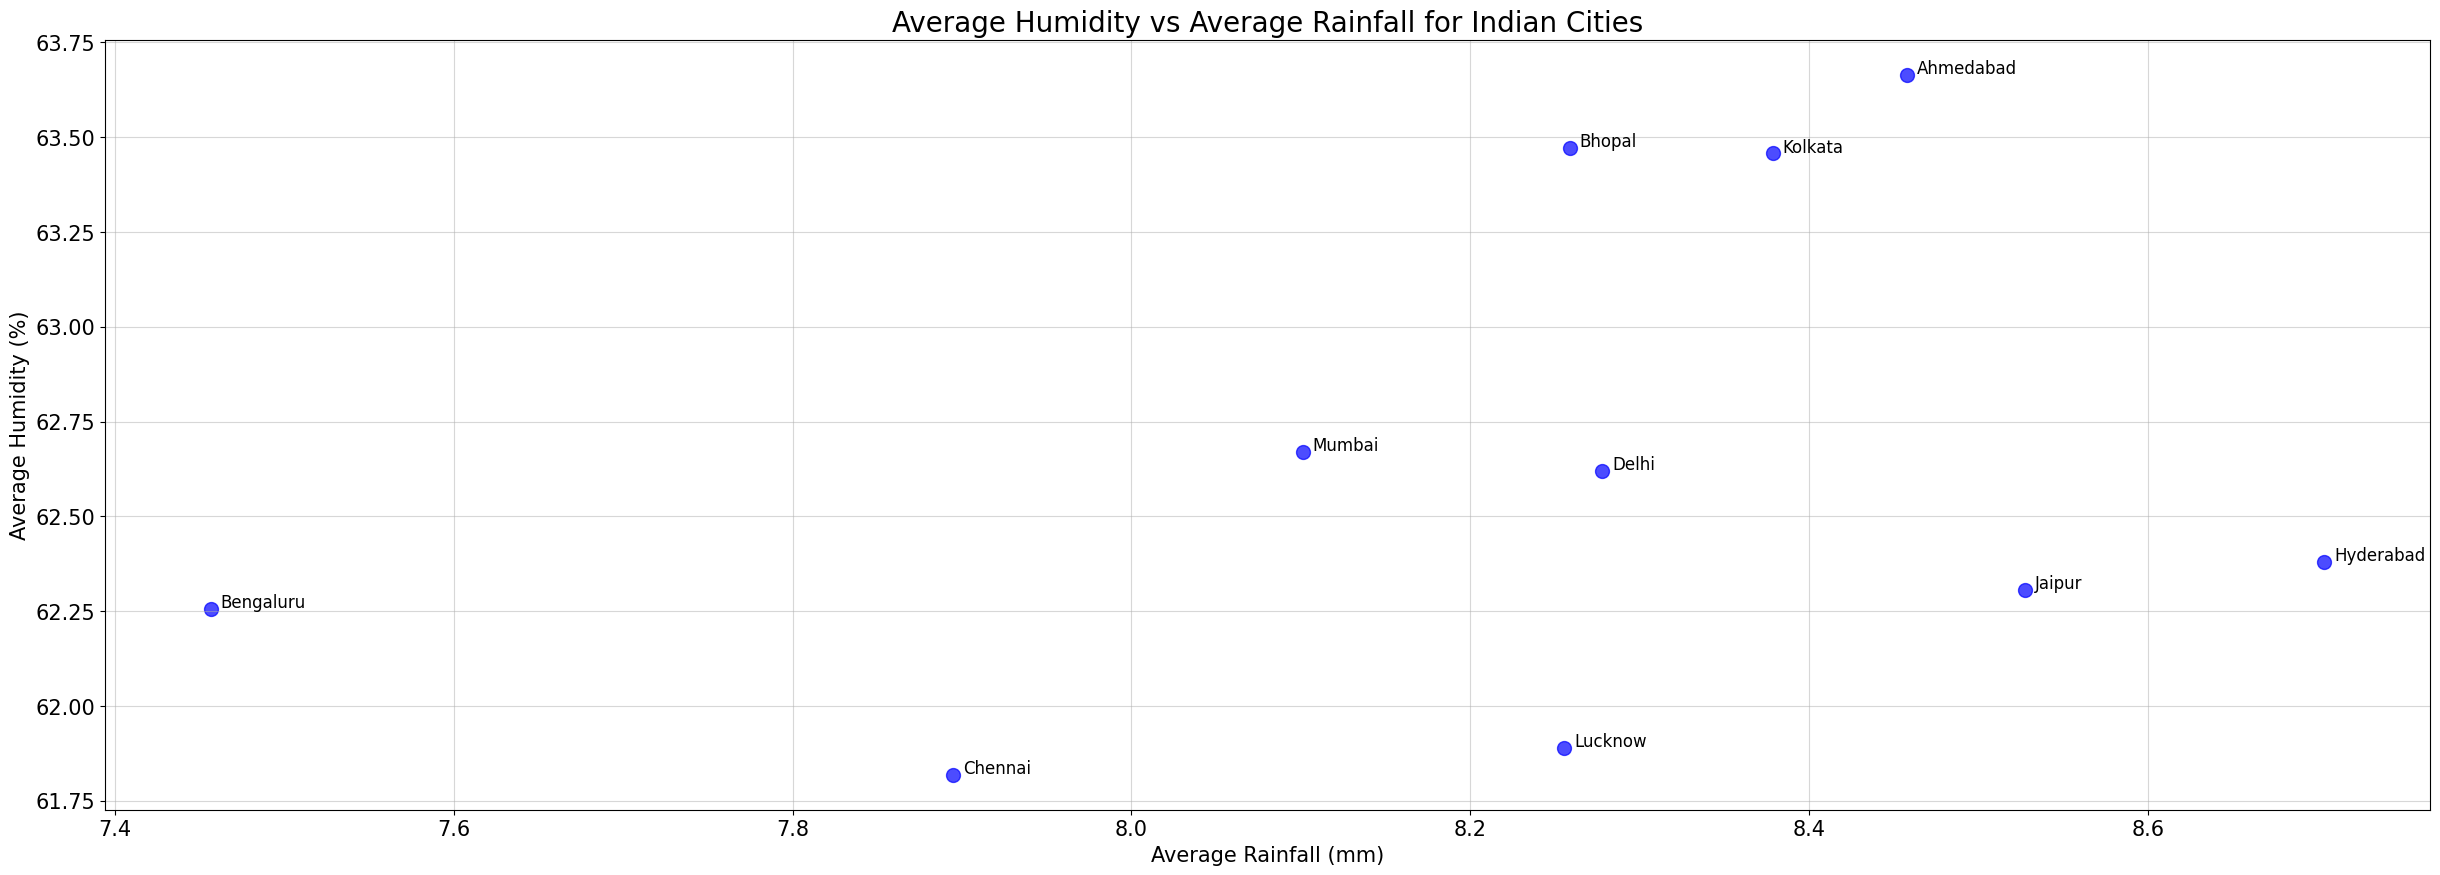

In [8]:

city_stats = df.groupby('City')[['Rainfall (mm)', 'Humidity (%)']].mean().reset_index()
plt.figure(figsize=(30, 10))
plt.scatter(city_stats['Rainfall (mm)'], city_stats['Humidity (%)'], s=100, alpha=0.7, color='blue')

for i, city in enumerate(city_stats['City']):
    plt.annotate(city, (city_stats['Rainfall (mm)'][i], city_stats['Humidity (%)'][i]), 
                 xytext=(7,1), textcoords='offset points', fontsize=12)
plt.xlabel('Average Rainfall (mm)', fontsize=15)
plt.ylabel('Average Humidity (%)', fontsize=15)
plt.title('Average Humidity vs Average Rainfall for Indian Cities', fontsize=20)
plt.grid(True, alpha=0.5)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

Cities like Ahmedabad, and Kolkata occupy the upper-right quadrant of the trend, showing both higher average rainfall and higher humidity levels.

Bengaluru shows the lowest average rainfall, with humidity levels around 62.2%.

Ahmedabad and Bhopal show some of the highest average humidity levels, while Chennai and Lucknow sit at the lower end of the humidity scale.

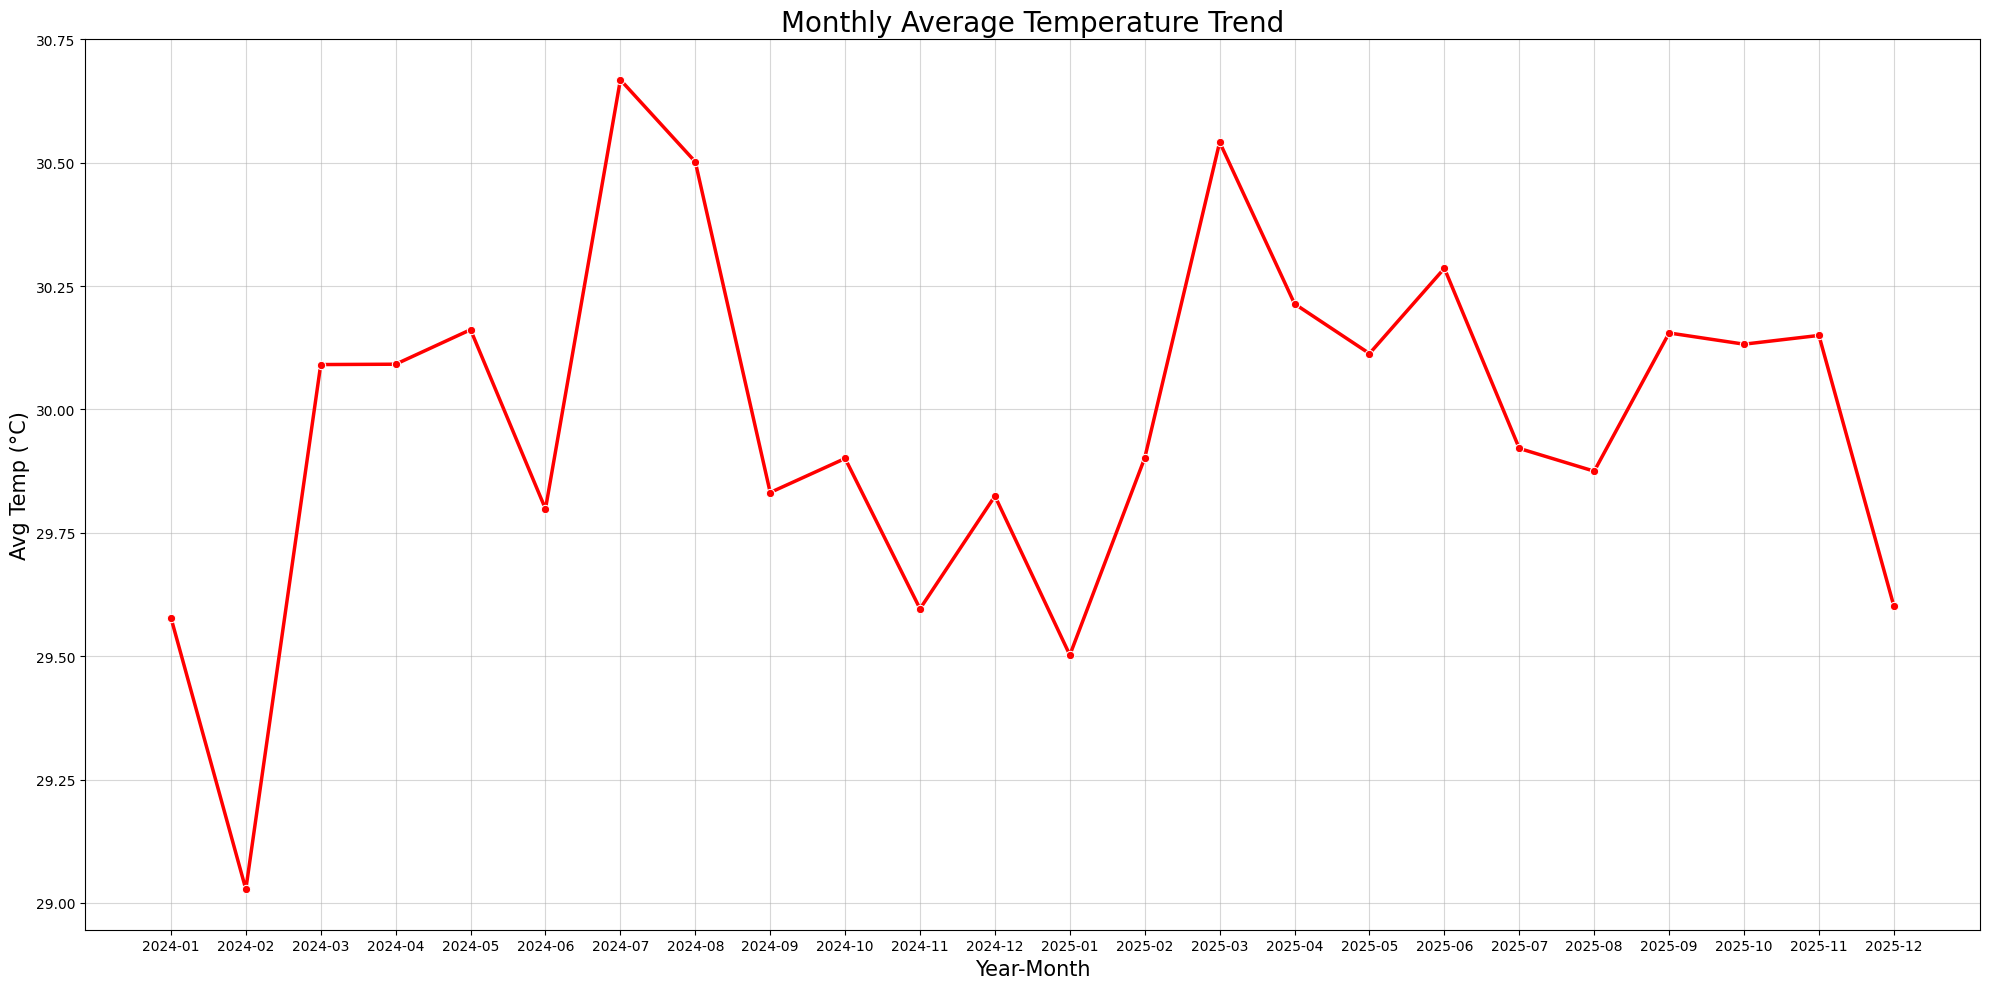

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)

plt.figure(figsize=(20, 10))
monthly_temp = df.groupby('YearMonth')['Temperature_Avg (°C)'].mean().reset_index()
sns.lineplot(data=monthly_temp, x='YearMonth', y='Temperature_Avg (°C)', marker='o', color='red', linewidth=2.5)
plt.title('Monthly Average Temperature Trend', fontsize=20)
plt.xlabel('Year-Month', fontsize=15)
plt.ylabel('Avg Temp (°C)', fontsize=15)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In this graph, the line will climb sharply starting in March, peaking around May/June (Pre-monsoon/Summer), dipping slightly during the heavy rains, and then falling to its lowest point in December/January.

By looking at the same month across two different years, you can determine if 2025 was generally hotter than 2024.

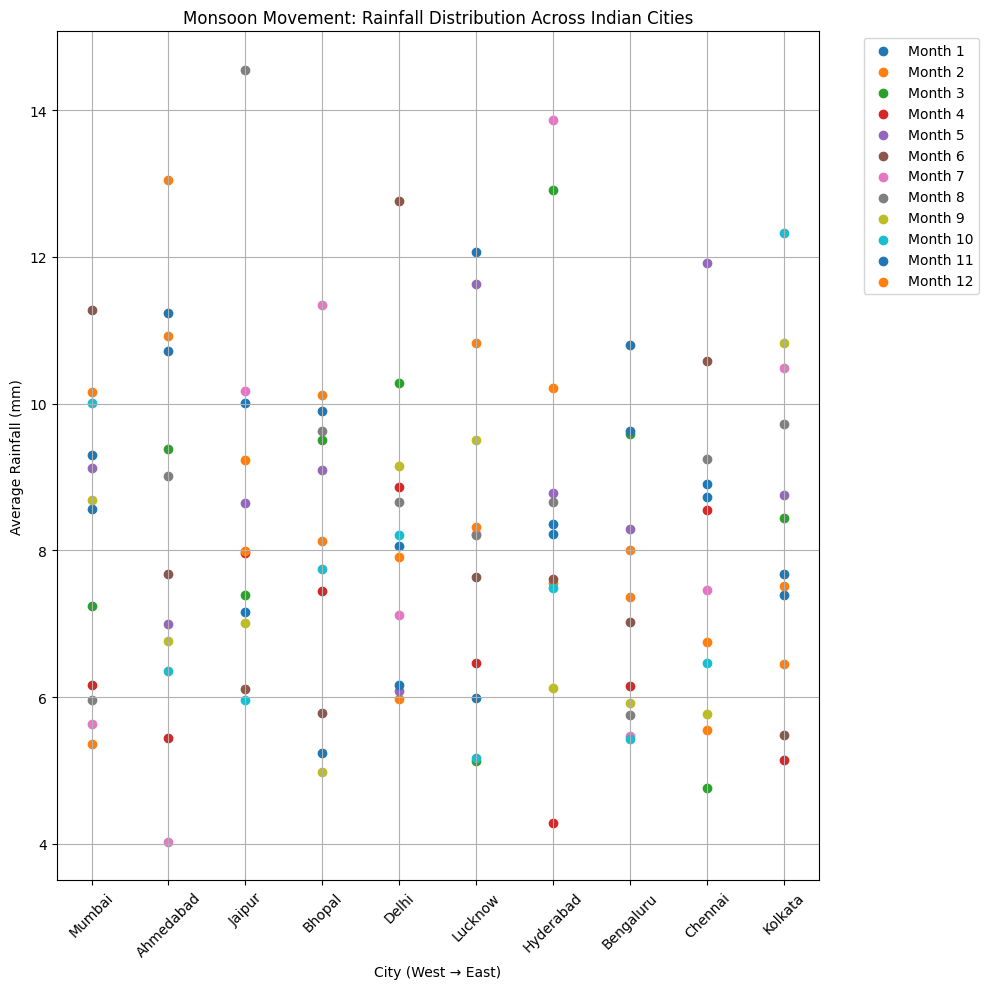

In [10]:
# Group rainfall
grouped = df.groupby(['Month','City'])['Rainfall (mm)'].mean().reset_index()

#  West → East ordering of cities
city_order = [
    'Mumbai',      # West coast
    'Ahmedabad',
    'Jaipur',
    'Bhopal',
    'Delhi',
    'Lucknow',
    'Hyderabad',
    'Bengaluru',
    'Chennai',
    'Kolkata'      # East coast
]

grouped['City'] = pd.Categorical(grouped['City'], categories=city_order, ordered=True)
grouped = grouped.sort_values('City')

# Plot
plt.figure(figsize = (10,10))

for month in sorted(grouped['Month'].unique()):
    subset = grouped[grouped['Month'] == month]
    plt.scatter(subset['City'], subset['Rainfall (mm)'], label=f'Month {month}')

plt.xticks(rotation=45)
plt.xlabel('City (West → East)')
plt.ylabel('Average Rainfall (mm)')
plt.title('Monsoon Movement: Rainfall Distribution Across Indian Cities')

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()

Plotting rainfall chronologically against a West-to-East city axis (Mumbai to Kolkata) provides a clear spatial narrative of the monsoon's movement.

This proves highly effective in tracking how precipitation fronts migrate across the country's longitudinal span as the months progress.

        City Region
6  Ahmedabad  North
2  Bengaluru  South
9     Bhopal  North
3    Chennai  South
1      Delhi  North
5  Hyderabad  South
7     Jaipur  North
4    Kolkata  North
8    Lucknow  North
0     Mumbai  North

Average Temperatures:
Region
North    29.987454
South    29.963247
Name: Temperature_Avg (°C), dtype: float64


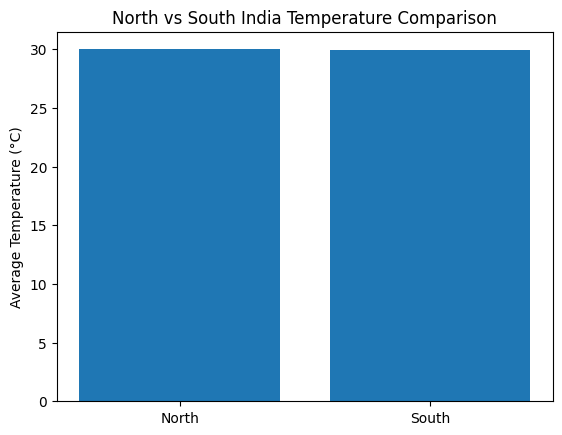

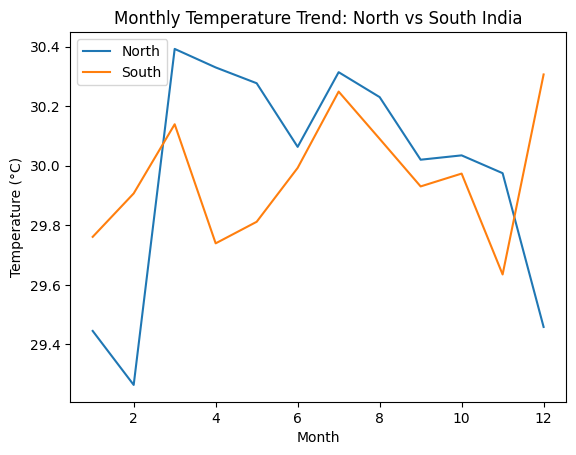

<Figure size 640x480 with 0 Axes>

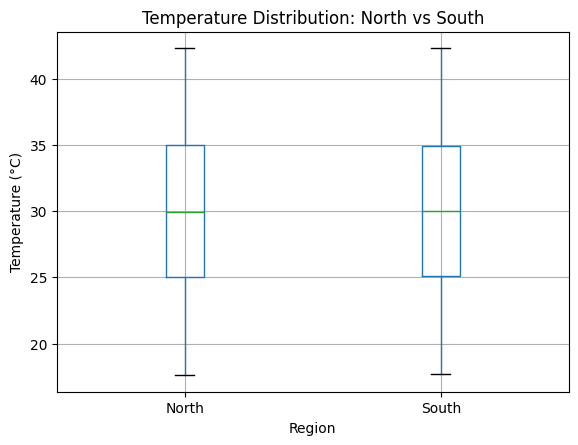

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

# Region Classification

# Define South Indian cities
south_cities = ['Bengaluru', 'Chennai', 'Hyderabad']

# Create a new column
df['Region'] = df['City'].apply(lambda x: 'South' if x in south_cities else 'North')

print(df[['City', 'Region']].drop_duplicates().sort_values('City'))

#Average Temperature Comparison
region_avg = df.groupby('Region')['Temperature_Avg (°C)'].mean()

print("\nAverage Temperatures:")
print(region_avg)

#plotting the Bar Chart
plt.figure()
plt.bar(region_avg.index, region_avg.values)
plt.ylabel('Average Temperature (°C)')
plt.title('North vs South India Temperature Comparison')
plt.show()
#  Monthly Trend Comparison
df['Month'] = df['Date'].dt.month

monthly_trend = df.groupby(['Month', 'Region'])['Temperature_Avg (°C)'].mean().unstack()

plt.figure()
plt.plot(monthly_trend.index, monthly_trend['North'], label='North')
plt.plot(monthly_trend.index, monthly_trend['South'], label='South')

plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.title('Monthly Temperature Trend: North vs South India')
plt.legend()
plt.show()

#Boxplot for North v/s South Temperature
plt.figure()
df.boxplot(column='Temperature_Avg (°C)', by='Region')
plt.title('Temperature Distribution: North vs South')
plt.suptitle('')
plt.ylabel('Temperature (°C)')
plt.show()

By bucketing Bengaluru, Chennai, and Hyderabad as "South" and the remaining cities as "North," the data reveals a surprisingly tight margin: North India averages 29.98°C, while South India averages 29.96°C.

The boxplots highlight the variance—North Indian cities likely experience much wider temperature swings (harrowing summers and colder winters), whereas the South maintains a tighter, more consistent thermal band year-round.

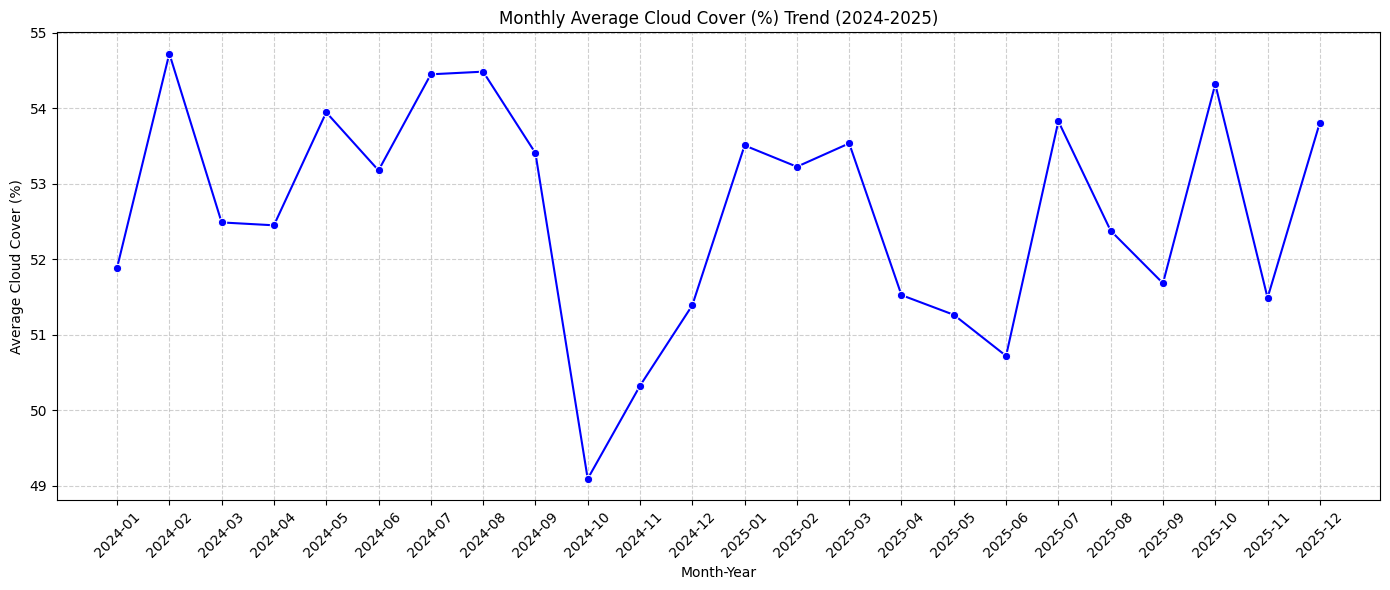

In [9]:
city_cloud = df.groupby('City')['Cloud_Cover (%)'].mean().sort_values(ascending=False).reset_index()
df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)
monthly_cloud = df.groupby('Month_Year')['Cloud_Cover (%)'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(x='Month_Year', y='Cloud_Cover (%)', data=monthly_cloud, marker='o', color='blue')
plt.title('Monthly Average Cloud Cover (%) Trend (2024-2025)')
plt.xlabel('Month-Year')
plt.ylabel('Average Cloud Cover (%)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

There are noticeable peaks in cloud cover during the monsoon months (typically June to September) and dips during the post-monsoon or early winter periods. 

This trend repeats across the two-year span, highlighting the cyclic nature of India's climate.

Top 5 cities with maximum Average Temperature throughout the Year
City
Kolkata      30.412722
Ahmedabad    30.144323
Bengaluru    30.080027
Delhi        30.074282
Hyderabad    29.978386
Name: Temperature_Avg (°C), dtype: float64


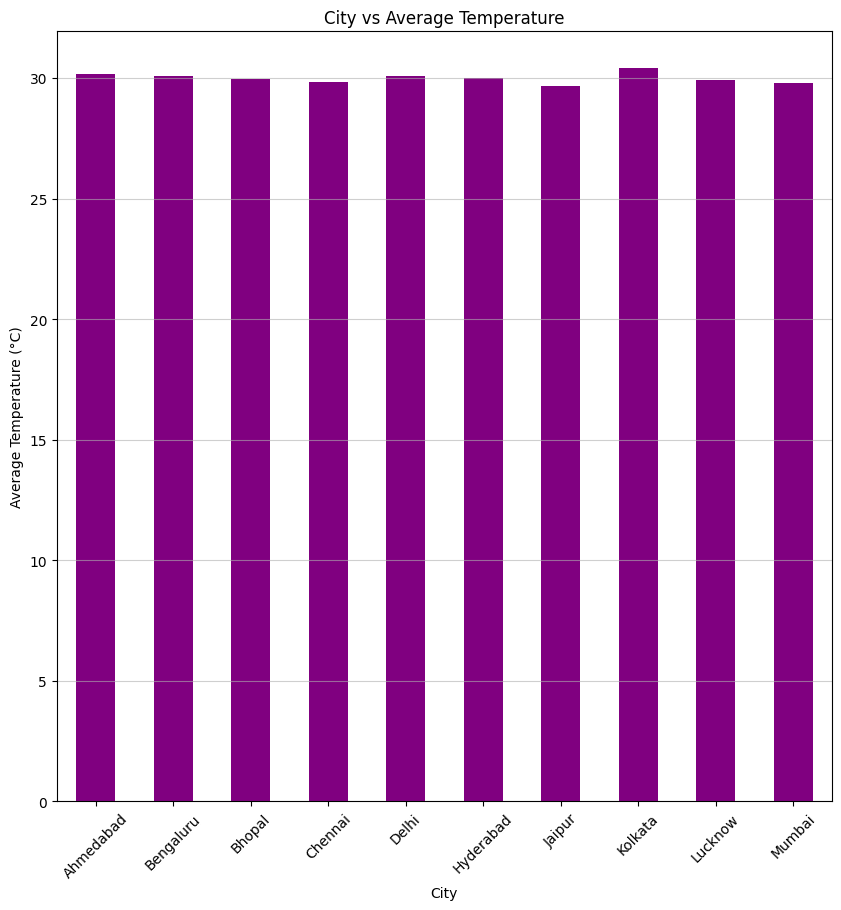

In [13]:
city_temp = df.groupby("City")["Temperature_Avg (°C)"].mean()
top_5_highest= city_temp.sort_values(ascending=False).head()
plt.figure(figsize=(10,10))
city_temp.plot(kind='bar',color = 'purple')
print("Top 5 cities with maximum Average Temperature throughout the Year")
print(top_5_highest)
plt.xlabel("City")
plt.ylabel("Average Temperature (°C)")
plt.title("City vs Average Temperature")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.6)
plt.show()

From the bar graph, it is visible that all the cities have almost similar average Temperatures throughout the year, ranging from 29-30 degree celsius with Ahmedabad having the maximum, crossing 30.

Top 3 Cities with high humidity and rainfall:-
           Humidity (%)  Rainfall (mm)
City                                  
Ahmedabad     63.664432       8.457729
Bengaluru     62.256772       7.456498
Bhopal        63.471819       8.258824


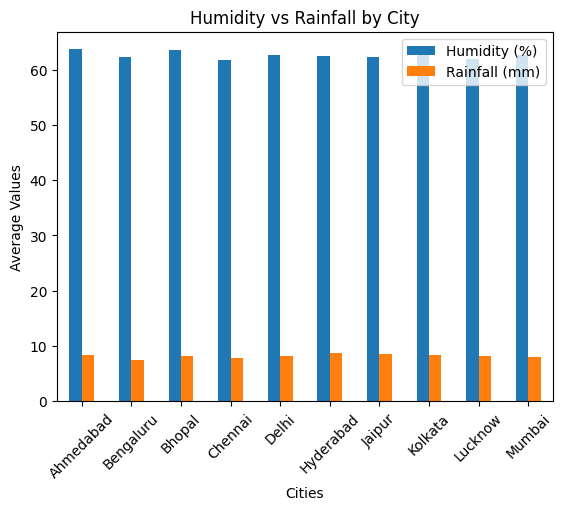

In [18]:
data = df.groupby("City")[["Humidity (%)", "Rainfall (mm)"]].mean()

print("Top 3 Cities with high humidity and rainfall:-")
print(data.head(3))
data.plot(kind='bar')
plt.title("Humidity vs Rainfall by City")
plt.xlabel("Cities")
plt.ylabel("Average Values")
plt.xticks(rotation=45)
plt.show()

Cities with high humidity usually have high rainfall.
Cities with low humidity tend to have less rainfall.
Even with high humidity, rainfall may vary. So, Relationship is strong but not perfectly linear